# Ride-Hailing Data Cleaning and EDA
Author: Dhiraj Karki


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [ ]:
df = pd.read_parquet("fhvhv_tripdata_2026-01.parquet") #data path

df.head()


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-01 00:50:37,2026-01-01 00:52:31,2026-01-01 00:54:30,2026-01-01 01:13:23,262,79,4.300,...,2.75,0.0,0.00,21.10,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2026-01-01 00:09:12,2026-01-01 00:12:17,2026-01-01 00:12:39,2026-01-01 00:22:42,195,52,1.890,...,0.00,0.0,0.00,9.10,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2026-01-01 00:16:16,2026-01-01 00:29:33,2026-01-01 00:31:34,2026-01-01 00:55:21,25,181,1.840,...,0.00,0.0,2.67,21.94,N,N,N,N,N,0.0
3,HV0005,B03406,NaN,2026-01-01 00:08:19,2026-01-01 00:09:08,2026-01-01 00:09:37,2026-01-01 00:22:12,141,226,3.307,...,2.75,0.0,0.00,13.42,N,N,N,N,Y,1.5
4,HV0005,B03406,NaN,2026-01-01 00:21:16,2026-01-01 00:26:30,2026-01-01 00:26:40,2026-01-01 00:39:06,226,226,2.060,...,0.00,0.0,2.98,11.39,N,N,N,N,Y,0.0


In [3]:
print("Shape of raw data:", df.shape)
print()
print("Columns in the dataset:")
print(df.columns)


Shape of raw data: (20940373, 25)

Columns in the dataset:
Index(['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num',
       'request_datetime', 'on_scene_datetime', 'pickup_datetime',
       'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles',
       'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax',
       'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay',
       'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag',
       'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee'],
      dtype='str')


In [4]:
columns_to_keep = [
    "hvfhs_license_num",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tolls",
    "tips",
    "driver_pay",
]

df = df[columns_to_keep].copy()

print(df.columns)


Index(['hvfhs_license_num', 'pickup_datetime', 'dropoff_datetime',
       'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time',
       'base_passenger_fare', 'tolls', 'tips', 'driver_pay'],
      dtype='str')


In [5]:
print("Shape after keeping useful columns:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))


Shape after keeping useful columns: (20940373, 11)

Data types:
hvfhs_license_num                 str
pickup_datetime        datetime64[us]
dropoff_datetime       datetime64[us]
PULocationID                    int32
DOLocationID                    int32
trip_miles                    float64
trip_time                       int64
base_passenger_fare           float64
tolls                         float64
tips                          float64
driver_pay                    float64
dtype: object

Missing values:


,missing_count
hvfhs_license_num,0
pickup_datetime,0
dropoff_datetime,0
PULocationID,0
DOLocationID,0
trip_miles,0
trip_time,0
base_passenger_fare,0
tolls,0
tips,0


In [6]:
df.describe().round(2)


,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,tips,driver_pay
count,20940373,20940373,20940373.00,20940373.00,20940373.00,20940373.00,20940373.00,20940373.00,20940373.00,20940373.00
mean,2026-01-17 01:21:53.479783,2026-01-17 01:40:38.742369,137.64,141.18,4.64,1125.22,25.65,0.98,1.16,19.83
min,2026-01-01 00:00:00,2026-01-01 00:00:56,1.00,1.00,0.00,0.00,-260.90,0.00,0.00,-29.68
25%,2026-01-09 15:58:58,2026-01-09 16:20:25,74.00,75.00,1.41,570.00,11.64,0.00,0.00,8.91
50%,2026-01-17 03:11:20,2026-01-17 03:28:16,138.00,140.00,2.69,921.00,18.53,0.00,0.00,15.02
75%,2026-01-24 12:40:03,2026-01-24 12:57:07,209.00,216.00,5.73,1453.00,30.58,0.00,0.00,25.14
max,2026-01-31 23:59:59,2026-02-01 04:46:31,265.00,265.00,1454.43,44998.00,1596.10,108.41,223.25,1243.91
std,NaN,NaN,75.34,78.39,5.56,792.21,24.02,3.43,3.49,16.93


## Data Cleaning


In [7]:
invalid_miles = df["trip_miles"] <= 0
invalid_time = df["trip_time"] <= 0
invalid_fare = df["base_passenger_fare"] <= 0
invalid_pay = df["driver_pay"] <= 0
invalid_time_order = df["pickup_datetime"] > df["dropoff_datetime"]

cleaning_summary = pd.DataFrame(
    {
        "Issue": [
            "trip_miles <= 0",
            "trip_time <= 0",
            "base_passenger_fare <= 0",
            "driver_pay <= 0",
            "pickup_datetime > dropoff_datetime",
        ],
        "Rows": [
            int(invalid_miles.sum()),
            int(invalid_time.sum()),
            int(invalid_fare.sum()),
            int(invalid_pay.sum()),
            int(invalid_time_order.sum()),
        ],
    }
)

cleaning_summary


,Issue,Rows
0,trip_miles <= 0,2782
1,trip_time <= 0,737
2,base_passenger_fare <= 0,100495
3,driver_pay <= 0,52209
4,pickup_datetime > dropoff_datetime,0


In [8]:
clean_df = df[
    (~invalid_miles)
    & (~invalid_time)
    & (~invalid_fare)
    & (~invalid_pay)
    & (~invalid_time_order)
].copy()

print("Raw shape:", df.shape)
print("Cleaned shape:", clean_df.shape)
print("Rows removed:", len(df) - len(clean_df))


Raw shape: (20940373, 11)
Cleaned shape: (20835764, 11)
Rows removed: 104609


In [9]:
clean_df["trip_minutes"] = clean_df["trip_time"] / 60
clean_df["total_fare"] = (
    clean_df["base_passenger_fare"] + clean_df["tolls"] + clean_df["tips"]
)
clean_df["fare_per_mile"] = clean_df["total_fare"] / clean_df["trip_miles"]
clean_df["speed_mph"] = clean_df["trip_miles"] / (clean_df["trip_minutes"] / 60)
clean_df["pickup_hour"] = clean_df["pickup_datetime"].dt.hour
clean_df["pickup_day"] = clean_df["pickup_datetime"].dt.day_name()

clean_df.head()


,hvfhs_license_num,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,tips,driver_pay,trip_minutes,total_fare,fare_per_mile,speed_mph,pickup_hour,pickup_day
0,HV0003,2026-01-01 00:54:30,2026-01-01 01:13:23,262,79,4.300,1133,31.24,0.0,0.00,21.10,18.883333,31.24,7.265116,13.662842,0,Thursday
1,HV0003,2026-01-01 00:12:39,2026-01-01 00:22:42,195,52,1.890,604,8.95,0.0,0.00,9.10,10.066667,8.95,4.735450,11.264901,0,Thursday
2,HV0003,2026-01-01 00:31:34,2026-01-01 00:55:21,25,181,1.840,1427,24.06,0.0,2.67,21.94,23.783333,26.73,14.527174,4.641906,0,Thursday
3,HV0005,2026-01-01 00:09:37,2026-01-01 00:22:12,141,226,3.307,755,24.91,0.0,0.00,13.42,12.583333,24.91,7.532507,15.768477,0,Thursday
4,HV0005,2026-01-01 00:26:40,2026-01-01 00:39:06,226,226,2.060,746,17.86,0.0,2.98,11.39,12.433333,20.84,10.116505,9.941019,0,Thursday


## EDA


In [10]:
plot_df = clean_df.sample(n=min(200000, len(clean_df)), random_state=42)

print("Sample used for plots:", len(plot_df))


Sample used for plots: 200000


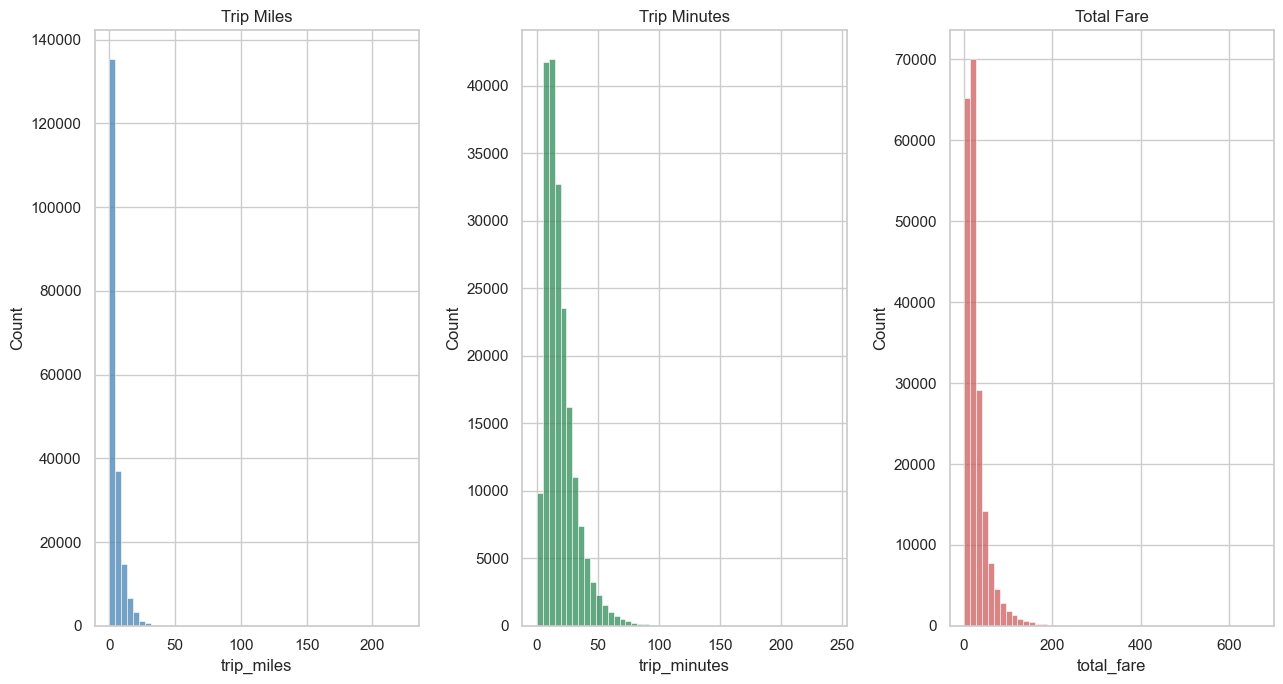

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 7))

sns.histplot(plot_df["trip_miles"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Trip Miles")

sns.histplot(plot_df["trip_minutes"], bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("Trip Minutes")

sns.histplot(plot_df["total_fare"], bins=50, ax=axes[2], color="indianred")
axes[2].set_title("Total Fare")

plt.tight_layout()
plt.show()


**Interpretation**  
These histograms show that most trips are relatively short, most ride durations are concentrated in a moderate range, and total fares are right-skewed, meaning a smaller number of trips are much more expensive than the rest.


In [12]:
hourly_trips = clean_df.groupby("pickup_hour").size().reset_index(name="trip_count")
hourly_trips


,pickup_hour,trip_count
0,0,729113
1,1,515611
2,2,386479
3,3,312938
4,4,321125
5,5,377823
6,6,582672
7,7,885308
8,8,1086674
9,9,990189


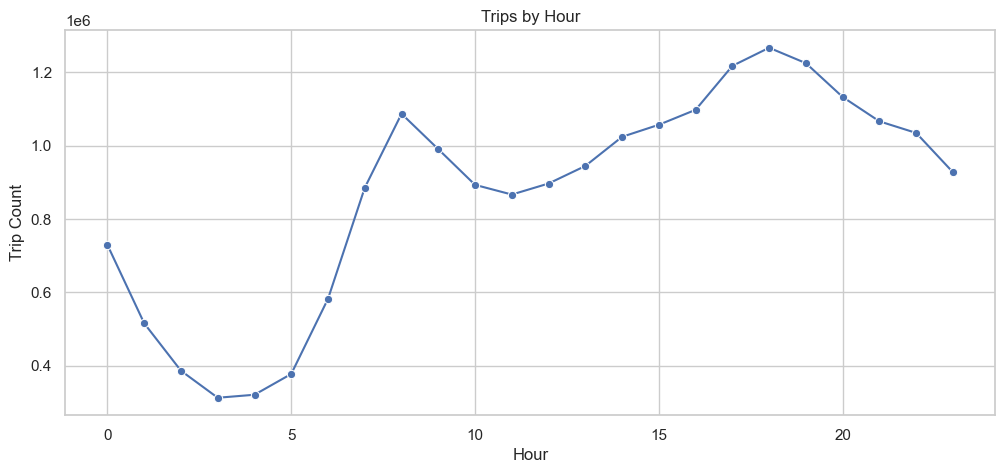

In [13]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_trips, x="pickup_hour", y="trip_count", marker="o")
plt.title("Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.show()


**Interpretation**  
The hourly line chart suggests that ride demand is not evenly distributed through the day. Demand rises sharply till 9 A.M and fades off then again the momentum catches up and reaaches peak at 7 P.M to 9 P.M


In [14]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_trips = clean_df.groupby("pickup_day").size().reset_index(name="trip_count")
daily_trips["pickup_day"] = pd.Categorical(daily_trips["pickup_day"], categories=day_order, ordered=True)
daily_trips = daily_trips.sort_values("pickup_day")

daily_trips


,pickup_day,trip_count
1,Monday,2198372
5,Tuesday,2535717
6,Wednesday,2605682
4,Thursday,3490202
0,Friday,3729861
2,Saturday,4044377
3,Sunday,2231553


/var/folders/h4/l312zs8d45l0sr4xh3qzkg7m0000gn/T/ipykernel_9682/1464845871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_trips, x="pickup_day", y="trip_count", palette="Blues_d")


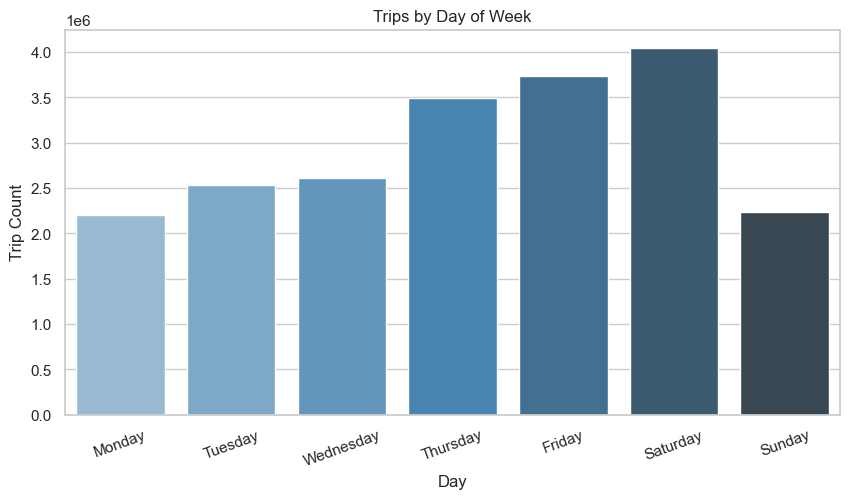

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_trips, x="pickup_day", y="trip_count", palette="Blues_d")
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Trip Count")
plt.xticks(rotation=20)
plt.show()


**Interpretation**  
This bar chart shows weekly demand differences. Sunday is the lest busy and as week continues it rises at peaks at Saturday, which may reflect work schedules, nightlife activity, or weekend travel behavior.

In [16]:
top_pickups = (
    clean_df.groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .head(10)
)

top_pickups


,PULocationID,trip_count
135,138,363510
129,132,329503
60,61,276475
36,37,245401
75,76,244790
78,79,241464
227,230,230390
158,161,225375
178,181,212904
228,231,212678


/var/folders/h4/l312zs8d45l0sr4xh3qzkg7m0000gn/T/ipykernel_9682/944501828.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_pickups, x="trip_count", y="PULocationID", palette="viridis")


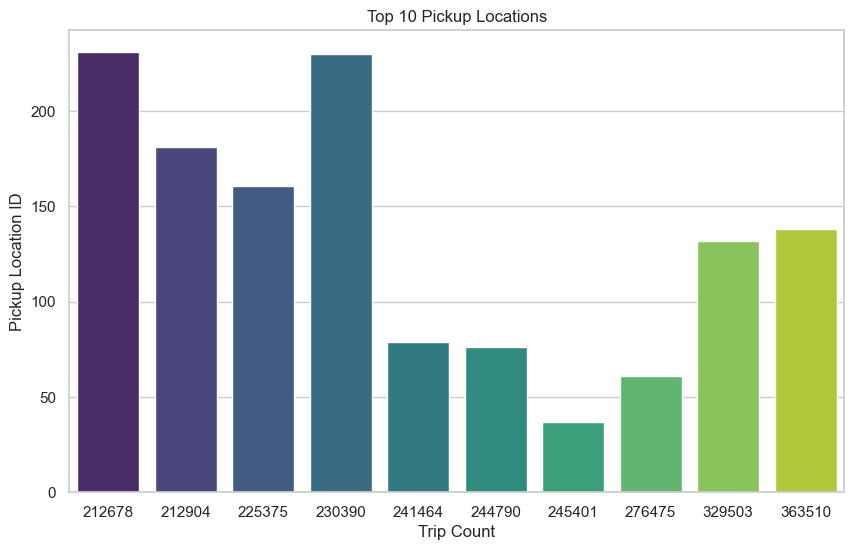

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_pickups, x="trip_count", y="PULocationID", palette="viridis")
plt.title("Top 10 Pickup Locations")
plt.xlabel("Trip Count")
plt.ylabel("Pickup Location ID")
plt.show()


**Interpretation**  
Trip demand is concentrated in a relatively small number of pickup locations. This suggests that ride-hailing activity is clustered geographically rather than spread evenly across all zones. The numbers are to be looked furthure into on what the actual location are rather than just the numbers indicating the location.


In [18]:
provider_summary = (
    clean_df.groupby("hvfhs_license_num")
    .agg(
        trip_count=("hvfhs_license_num", "size"),
        avg_trip_miles=("trip_miles", "mean"),
        avg_total_fare=("total_fare", "mean"),
    )
    .round(2)
    .reset_index()
)

provider_summary


,hvfhs_license_num,trip_count,avg_trip_miles,avg_total_fare
0,HV0003,15183583,4.70,28.38
1,HV0005,5652181,4.47,26.73


**Interpretation**  
The provider summary suggests that the two providers do not contribute equally to the market. Uber handles many more trips, and there are also small differences in average distance and average fare.

HV0003 → Uber                                                                               
HV0005 → Lyft


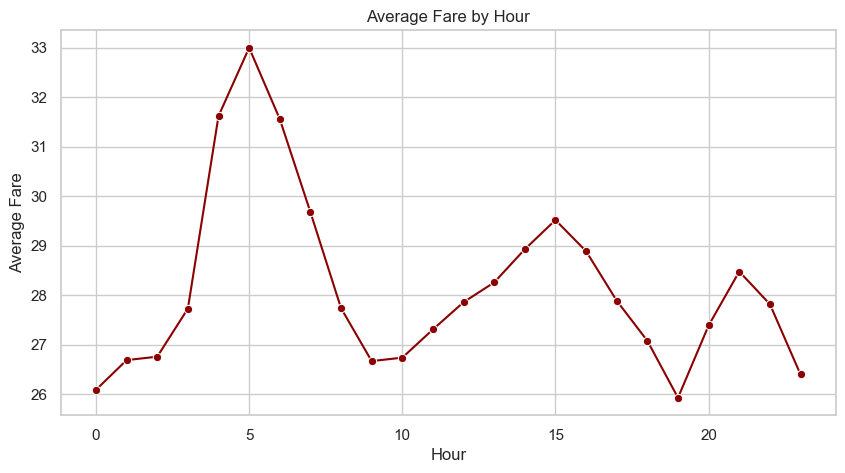

In [19]:
hourly_fare_summary = (
    clean_df.groupby("pickup_hour")
    .agg(
        avg_total_fare=("total_fare", "mean"),
        avg_trip_miles=("trip_miles", "mean"),
    )
    .round(2)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_fare_summary, x="pickup_hour", y="avg_total_fare", marker="o", color="darkred")
plt.title("Average Fare by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Fare")
plt.show()

**Interpretation**  
This line chart shows how average fare changes across the day. This shows high cost in the early morning as its not a suitable time for people to order the rides. 

Also noticeable thing is as the rides gets busy the fare goes low and vice versa

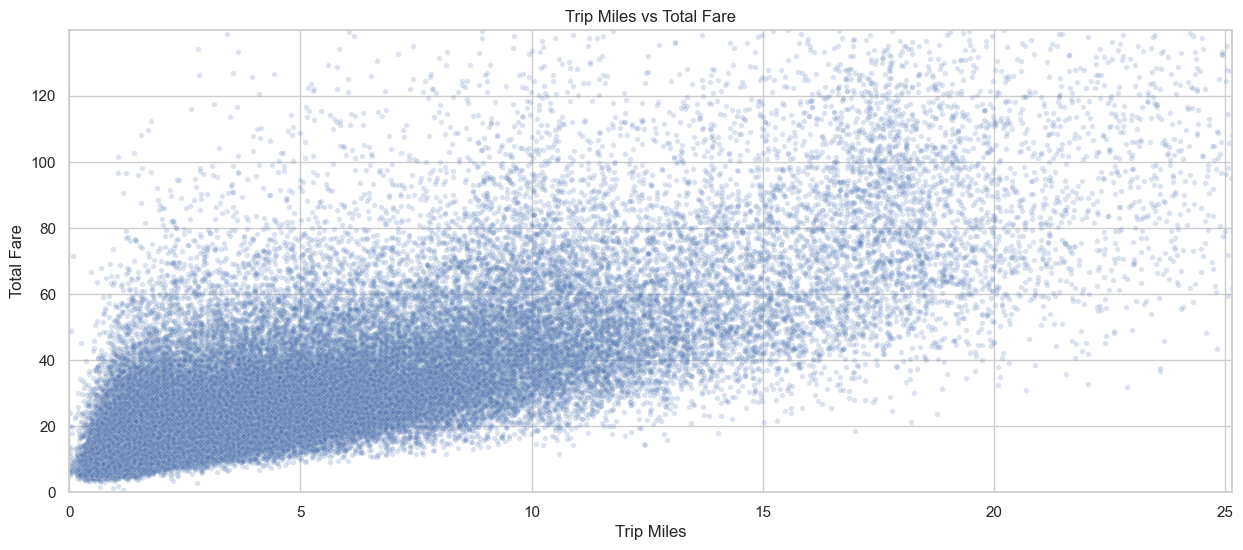

In [20]:
sample_scatter = clean_df.sample(n=min(100000, len(clean_df)), random_state=42).copy()
x_limit = sample_scatter["trip_miles"].quantile(0.99)
y_limit = sample_scatter["total_fare"].quantile(0.99)

zoom_scatter = sample_scatter[
    (sample_scatter["trip_miles"] <= x_limit)
    & (sample_scatter["total_fare"] <= y_limit)
]

plt.figure(figsize=(15, 6))
sns.scatterplot(data=zoom_scatter, x="trip_miles", y="total_fare", alpha=0.2, s=15)
plt.title("Trip Miles vs Total Fare")
plt.xlabel("Trip Miles")
plt.ylabel("Total Fare")
plt.xlim(0, x_limit)
plt.ylim(0, y_limit)
plt.show()

**Interpretation**  
This gives the relation of fare with miles and can later be used to train ML model.

In [21]:
hour_day_heatmap = clean_df.pivot_table(
    index="pickup_day",
    columns="pickup_hour",
    values="hvfhs_license_num",
    aggfunc="count"
)

hour_day_heatmap = hour_day_heatmap.reindex(day_order)

hour_day_heatmap


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day,,,,,,,,,,,,,,,,,,,,,
Monday,59539,36013,24530,21406,27885,40698,67107,104649,131757,116613,...,117076,122218,125512,137558,138854,124404,112777,105406,95247,82038
Tuesday,54693,30816,20956,19110,28952,48144,85110,139302,174509,149018,...,128988,131633,137458,158924,158845,145640,138426,130288,114653,90803
Wednesday,60086,33723,22402,20147,29822,48638,88655,145722,181909,150192,...,128400,130646,138001,158529,161589,152244,141843,136881,124440,98959
Thursday,121811,99595,84463,72025,67426,74232,108938,166937,198894,166686,...,161629,168875,175802,199816,204702,196697,184448,175286,166426,141936
Friday,103236,62348,42385,36437,46696,65262,108099,170664,208845,176296,...,180148,184414,193794,218684,237638,239487,214745,202572,209062,204203
Saturday,176849,135659,102297,77373,66080,58004,74291,95262,121151,147354,...,196459,207239,215011,231357,249155,257131,239125,220783,231212,226991
Sunday,152899,117457,89446,66440,54264,42845,50472,62772,69609,84030,...,111207,111726,111948,112343,115810,108992,101083,94880,93435,82499


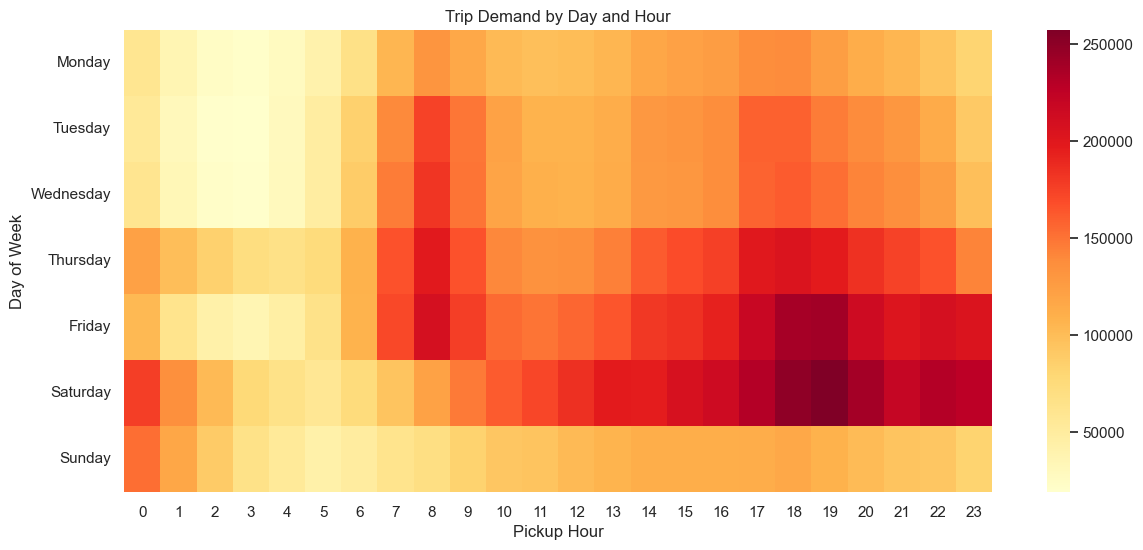

In [22]:
plt.figure(figsize=(14, 6))
sns.heatmap(hour_day_heatmap, cmap="YlOrRd")
plt.title("Trip Demand by Day and Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.show()


**Interpretation**  
The heatmap gives a stronger view of demand by combining both day and hour. It helps identify exactly when trip activity is most concentrated instead of looking at day and hour separately.

In [23]:
correlation_table = clean_df[
    ["trip_miles", "trip_minutes", "total_fare", "fare_per_mile", "speed_mph"]
].corr().round(2)

correlation_table


,trip_miles,trip_minutes,total_fare,fare_per_mile,speed_mph
trip_miles,1.00,0.78,0.84,-0.12,0.75
trip_minutes,0.78,1.00,0.78,-0.10,0.34
total_fare,0.84,0.78,1.00,-0.01,0.51
fare_per_mile,-0.12,-0.10,-0.01,1.00,-0.17
speed_mph,0.75,0.34,0.51,-0.17,1.00


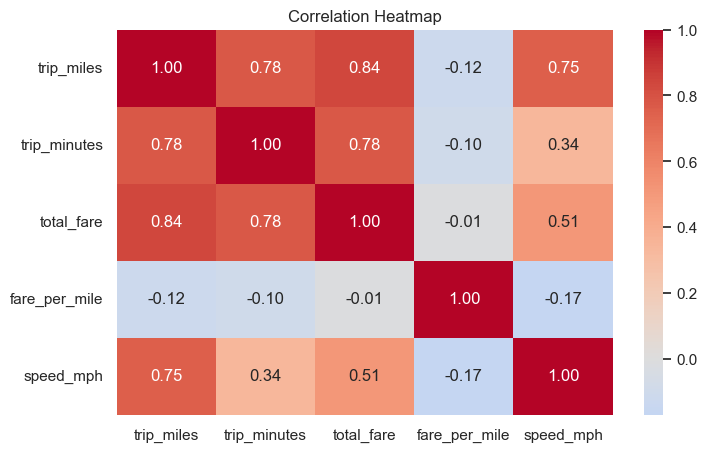

In [24]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()


**Interpretation**  
The correlation heatmap summarizes the strength and direction of relationships among the main numeric variables. High positive correlation of trip_miles vs total_fare, trip_miles vs total_fare, and high negative correlation with total_fare vs fare_per_mile


## Initial Findings

- Ride demand changes across the day, with the highest activity occurring in the late afternoon and evening hours along with a spike in work time at the morning.
- Demand also changes across the week, with Saturday showing the highest trip volume and Sunday lower than most other days signaling the weekend and nightlife activities.
- Ride-hailing activity is concentrated in a relatively small number of pickup location IDs, which suggests strong geographic clustering.
- Trip distance and total fare have a strong positive relationship, meaning longer trips usually cost more.
- The hourly fare plot suggests that average fare also changes by time of day, likely because trip distance and trip behavior vary across the day.
- The day-by-hour heatmap shows that demand depends on both the day of week and the hour, not just one of them separately.


## Further Exploration

1. The evening demand peak may be related to commuting activity, nightlife, and airport travel.
2. The busiest pickup location IDs may correspond to business districts, transportation hubs, or dense residential areas.
3. Higher average fares in some hours may be linked to longer average trip distances rather than demand alone.
4. Some pickup zones may consistently produce longer, more expensive, or slower trips than others.
5. Provider-level differences may reflect different customer groups, service areas, or pricing structures.
6. Trip efficiency, measured through speed and duration, may vary by time of day because of traffic congestion.
